In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!pip install numba

In [16]:
import matplotlib.pyplot as plt
import numba
from numba import cuda
import numpy as np
import time
import math

Image size: 718 x 718
Pixels count: 515524


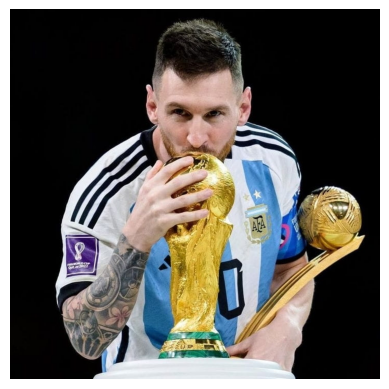

In [17]:
img = plt.imread('/content/drive/MyDrive/Dataset/HPC/wc.jpg')
h, w, _ = img.shape
pixelCount = h * w

print(f"Image size: {h} x {w}")
print(f"Pixels count: {pixelCount}")

plt.imshow(img)
plt.axis("off")
plt.show()

**Grayscale image binarization**



Converting RGB to Grayscale

In [18]:
@cuda.jit
def rgb2binary_gpu_2d(rgb, binary, threshold):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  g = np.uint8((rgb[tidy, tidx, 0] + rgb[tidy, tidx, 1] + rgb[tidy, tidx, 2]) / 3)
  b = np.uint8(255) if g >= threshold else np.uint8(0)
  binary[tidy, tidx, 0] = binary[tidy, tidx, 1] = binary[tidy, tidx, 2] = b

def binary_gpu_2d(rgb, blockSize, threshold):
  h, w, _ = rgb.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  rgb_gpu = cuda.to_device(rgb)
  binary_gpu = cuda.device_array((h, w, 3), np.uint8)
  rgb2binary_gpu_2d[gridSize, blockSize](rgb_gpu, binary_gpu, threshold)
  host_binary_gpu = binary_gpu.copy_to_host()
  return host_binary_gpu

def gpu_time_binary(img, blockSize, n_runs, threshold):
  binary_gpu_2d(img, blockSize, threshold)

  times = []
  for i in range(n_runs):
      start = time.time()
      host_binary_gpu = binary_gpu_2d(img, blockSize, threshold)
      times.append(time.time() - start)
      print(f"Run {i+1:2d}: {times[-1]:.4f}s")

  mean_t, std_t = np.mean(times), np.std(times)
  print(f"\nGPU time with 2D block size = {blockSize}: {mean_t:.4f}s ± {std_t:.4f}s (mean of {N_RUNS} runs)")

  return host_binary_gpu, mean_t, std_t


Run  1: 0.0033s
Run  2: 0.0019s
Run  3: 0.0017s
Run  4: 0.0017s
Run  5: 0.0017s
Run  6: 0.0018s
Run  7: 0.0031s
Run  8: 0.0017s
Run  9: 0.0017s
Run 10: 0.0017s

GPU time with 2D block size = (32, 32): 0.0020s ± 0.0006s (mean of 10 runs)


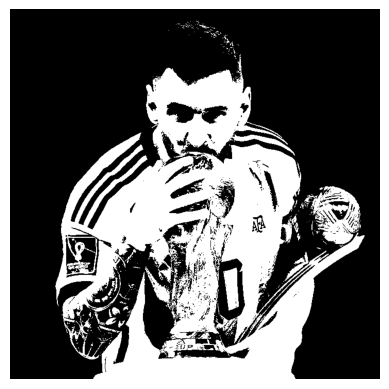

In [19]:
blockSize = (32, 32)
N_RUNS = 10
threshold = 128

binary_gpu_img, _, _ = gpu_time_binary(img, blockSize, N_RUNS, threshold)

plt.imshow(binary_gpu_img)
plt.axis("off")
plt.savefig("binary_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

Brightness control

In [20]:
@cuda.jit
def brightness_gpu_2d(img, bright, bright_value):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w, _ = img.shape
  if tidy < h and tidx < w:
    for c in range(3):
      br = int(img[tidy, tidx, c]) + bright_value
      if br > 255:
        br = 255
      elif br < 0:
        br = 0
      bright[tidy, tidx, c] = np.uint8(br)

def brightness_gpu(img, blockSize, bright_value):
  h, w, _ = img.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  rgb_gpu = cuda.to_device(img)
  out_gpu = cuda.device_array((h, w, 3), np.uint8)
  brightness_gpu_2d[gridSize, blockSize](rgb_gpu, out_gpu, bright_value)
  host_out = out_gpu.copy_to_host()
  return host_out

def gpu_time_brightness(img, blockSize, n_runs, bright_value):
  brightness_gpu(img, blockSize, bright_value)

  times = []
  for i in range(n_runs):
      start = time.time()
      bright_img = brightness_gpu(img, blockSize, bright_value)
      times.append(time.time() - start)
      print(f"Run {i+1:2d}: {times[-1]:.4f}s")

  mean_t, std_t = np.mean(times), np.std(times)
  print(f"\nGPU brightness (bright value={bright_value}) with 2D block size = {blockSize}: {mean_t:.4f}s ± {std_t:.4f}s (mean of {n_runs} runs)")

  return bright_img, mean_t, std_t


Run  1: 0.0030s
Run  2: 0.0020s
Run  3: 0.0014s
Run  4: 0.0016s
Run  5: 0.0015s
Run  6: 0.0015s
Run  7: 0.0027s
Run  8: 0.0016s
Run  9: 0.0014s
Run 10: 0.0014s

GPU brightness (bright value=100) with 2D block size = (32, 32): 0.0018s ± 0.0006s (mean of 10 runs)
Run  1: 0.0027s
Run  2: 0.0014s
Run  3: 0.0016s
Run  4: 0.0015s
Run  5: 0.0015s
Run  6: 0.0014s
Run  7: 0.0027s
Run  8: 0.0014s
Run  9: 0.0015s
Run 10: 0.0014s

GPU brightness (bright value=-100) with 2D block size = (32, 32): 0.0017s ± 0.0005s (mean of 10 runs)


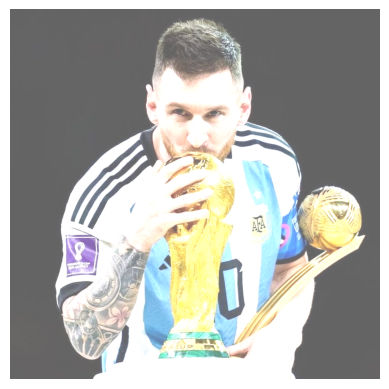

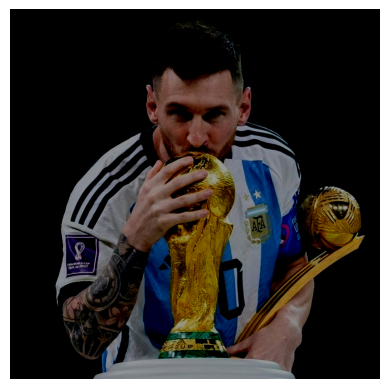

In [21]:
bright_value = 100
dark_value = -100
brighter_gpu_img, _, _ = gpu_time_brightness(img, blockSize, N_RUNS, bright_value)
darker_gpu_img, _, _ = gpu_time_brightness(img, blockSize, N_RUNS, dark_value)

plt.imshow(brighter_gpu_img)
plt.axis("off")
plt.savefig("brighter_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

plt.imshow(darker_gpu_img)
plt.axis("off")
plt.savefig("darker_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

Blending Images

Image size: 718 x 718
Pixels count: 515524


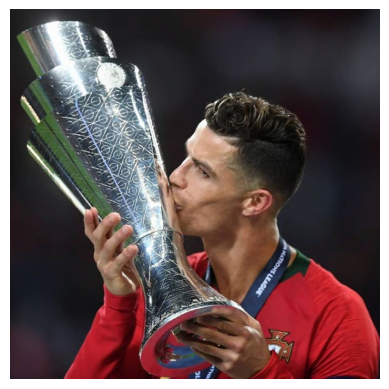

In [22]:
img2 = plt.imread('/content/drive/MyDrive/Dataset/HPC/cr.jpg')
h, w, _ = img2.shape
pixelCount = h * w

print(f"Image size: {h} x {w}")
print(f"Pixels count: {pixelCount}")

plt.imshow(img2)
plt.axis("off")
plt.show()

In [28]:
@cuda.jit
def blend_gpu_2d(img1, img2, blend_output, c):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w, _ = img1.shape
  if tidy < h and tidx < w:
    for channel in range(3):
      bl = c * img1[tidy, tidx, channel] + (1 - c) * img2[tidy, tidx, channel]
      blend_output[tidy, tidx, channel] = np.uint8(bl)

def blend_gpu(img1, img2, blockSize, c):
  h, w, _ = img1.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  img1_gpu = cuda.to_device(img1)
  img2_gpu = cuda.to_device(img2)
  blend_output_gpu = cuda.device_array((h, w, 3), np.uint8)
  blend_gpu_2d[gridSize, blockSize](img1_gpu, img2_gpu, blend_output_gpu, c)
  host_blend_output = blend_output_gpu.copy_to_host()
  return host_blend_output

def gpu_time_blend(img1, img2, blockSize, n_runs, c):
  blend_gpu(img1, img2, blockSize, c)

  times = []
  for i in range(n_runs):
      start = time.time()
      blend_img = blend_gpu(img1, img2, blockSize, c)
      times.append(time.time() - start)
      print(f"Run {i+1:2d}: {times[-1]:.4f}s")

  mean_t, std_t = np.mean(times), np.std(times)
  print(f"\nGPU blend (c={c}) with 2D block size = {blockSize}: {mean_t:.4f}s ± {std_t:.4f}s (mean of {n_runs} runs)")

  return blend_img, mean_t, std_t

Run  1: 0.0027s
Run  2: 0.0039s
Run  3: 0.0024s
Run  4: 0.0023s
Run  5: 0.0024s
Run  6: 0.0036s
Run  7: 0.0023s
Run  8: 0.0023s
Run  9: 0.0023s
Run 10: 0.0036s
Run 11: 0.0024s
Run 12: 0.0024s
Run 13: 0.0035s
Run 14: 0.0024s
Run 15: 0.0023s
Run 16: 0.0023s
Run 17: 0.0036s
Run 18: 0.0023s
Run 19: 0.0023s
Run 20: 0.0023s
Run 21: 0.0038s
Run 22: 0.0023s
Run 23: 0.0023s
Run 24: 0.0037s
Run 25: 0.0024s
Run 26: 0.0023s
Run 27: 0.0023s
Run 28: 0.0036s
Run 29: 0.0023s
Run 30: 0.0023s

GPU blend (c=0.5) with 2D block size = (32, 16): 0.0027s ± 0.0006s (mean of 30 runs)


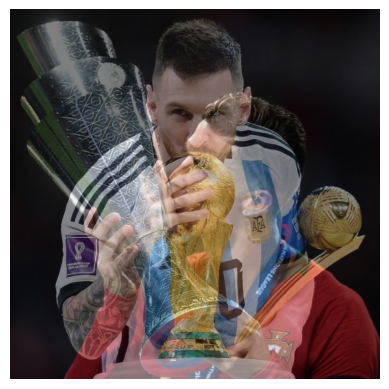

In [29]:
c = 0.5
blend_img, _, _ = gpu_time_blend(img, img2, blockSize, N_RUNS, c)

plt.imshow(blend_img)
plt.axis("off")
plt.savefig("blend_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

**Experimenting with different 2D block size**

In [39]:
BLOCK_SIZE_2D = [(8,8), (8,16), (16,8), (8,32), (32,8), (16,16), (32,32), (16,32), (32,16)]
N_RUNS = 10
threshold = 128
bright_value = 100
c = 0.5

means_binary, stds_binary = [], []
means_bright, stds_bright = [], []
means_blend, stds_blend = [], []

for blockSize in BLOCK_SIZE_2D:
    _, mean_b, std_b = gpu_time_binary(img, blockSize, N_RUNS, threshold)
    _, mean_br, std_br = gpu_time_brightness(img, blockSize, N_RUNS, bright_value)
    _, mean_bl, std_bl = gpu_time_blend(img, img2, blockSize, N_RUNS, c)

    means_binary.append(mean_b);  stds_binary.append(std_b)
    means_bright.append(mean_br); stds_bright.append(std_br)
    means_blend.append(mean_bl);  stds_blend.append(std_bl)

labels = [f"{x}x{y}" for x, y in BLOCK_SIZE_2D]

print(f"{'Block size'} | {'Binary (ms)'} | {'Brightness (ms)'} | {'Blend (ms)'}")
for label, mb, mbr, mbl in zip(labels, means_binary, means_bright, means_blend):
    print(f"{label} | {mb:.4f} | {mbr:.4f} | {mbl:.4f}")

Run  1: 0.0024s
Run  2: 0.0020s
Run  3: 0.0019s
Run  4: 0.0034s
Run  5: 0.0019s
Run  6: 0.0019s
Run  7: 0.0019s
Run  8: 0.0018s
Run  9: 0.0033s
Run 10: 0.0018s

GPU time with 2D block size = (8, 8): 0.0022s ± 0.0006s (mean of 10 runs)
Run  1: 0.0018s
Run  2: 0.0018s
Run  3: 0.0018s
Run  4: 0.0040s
Run  5: 0.0019s
Run  6: 0.0020s
Run  7: 0.0025s
Run  8: 0.0023s
Run  9: 0.0040s
Run 10: 0.0025s

GPU brightness (bright value=100) with 2D block size = (8, 8): 0.0025s ± 0.0008s (mean of 10 runs)
Run  1: 0.0034s
Run  2: 0.0048s
Run  3: 0.0029s
Run  4: 0.0040s
Run  5: 0.0029s
Run  6: 0.0053s
Run  7: 0.0031s
Run  8: 0.0028s
Run  9: 0.0030s
Run 10: 0.0044s

GPU blend (c=0.5) with 2D block size = (8, 8): 0.0037s ± 0.0009s (mean of 10 runs)
Run  1: 0.0022s
Run  2: 0.0020s
Run  3: 0.0018s
Run  4: 0.0034s
Run  5: 0.0018s
Run  6: 0.0020s
Run  7: 0.0019s
Run  8: 0.0020s
Run  9: 0.0034s
Run 10: 0.0020s

GPU time with 2D block size = (8, 16): 0.0023s ± 0.0006s (mean of 10 runs)
Run  1: 0.0019s
Run  2: 0

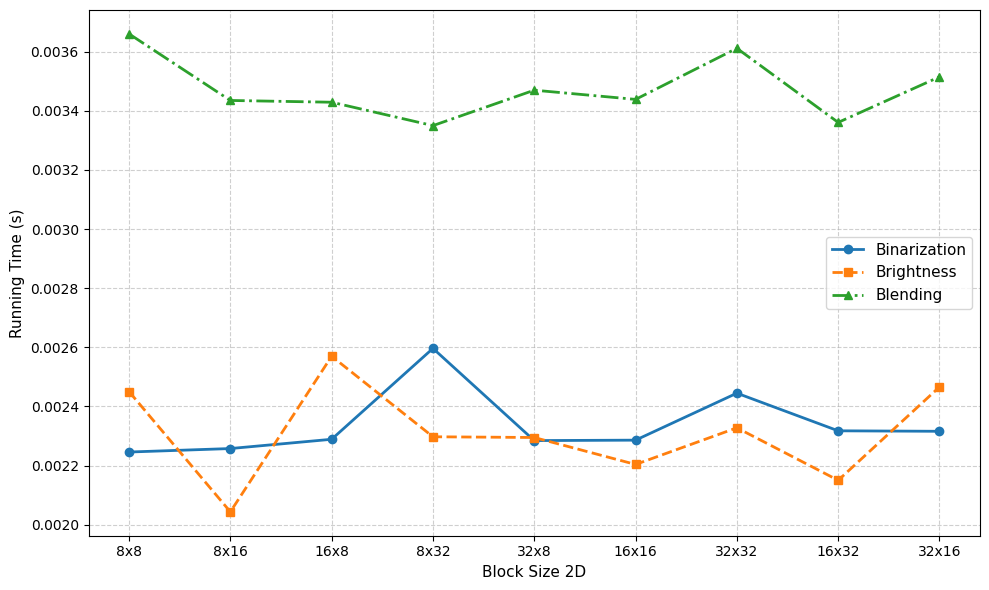

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(labels, means_binary, marker="o", linewidth=2, linestyle="-",  label="Binarization")
plt.plot(labels, means_bright, marker="s", linewidth=2, linestyle="--", label="Brightness")
plt.plot(labels, means_blend,  marker="^", linewidth=2, linestyle="-.", label="Blending")
plt.xlabel("Block Size 2D", fontsize=11)
plt.ylabel("Running Time (s)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("blocksize_2d_different.png", dpi=150, bbox_inches="tight")
plt.show()